# FairCheck: Bias Detection Tool

This project evaluates whether a binary prediction model shows different outcomes across demographic groups.

## Goal
The tool measures fairness-related differences in model performance across groups using:
- selection rate
- accuracy
- false positive rate
- false negative rate

## Ethical Purpose
This project supports responsible AI use by helping users identify possible bias before model outputs affect real people.

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# sample data 
data = pd.DataFrame({
    "group": [
        "Group A","Group A","Group A","Group A","Group A","Group A","Group A","Group A",
        "Group B","Group B","Group B","Group B","Group B","Group B","Group B","Group B"
    ],
    "actual": [1,1,1,0,0,0,1,0, 1,1,0,0,1,0,1,0],
    "predicted": [1,1,0,1,0,0,1,1, 1,0,0,0,1,0,0,0]
})

data

,group,actual,predicted
0,Group A,1,1
1,Group A,1,1
2,Group A,1,0
3,Group A,0,1
4,Group A,0,0
5,Group A,0,0
6,Group A,1,1
7,Group A,0,1
8,Group B,1,1
9,Group B,1,0


In [4]:
# compute fairness
def compute_group_metrics(df, group_col="group", actual_col="actual", pred_col="predicted"):
    results = []

    for group in df[group_col].unique():
        subset = df[df[group_col] == group]

        tp = ((subset[actual_col] == 1) & (subset[pred_col] == 1)).sum()
        tn = ((subset[actual_col] == 0) & (subset[pred_col] == 0)).sum()
        fp = ((subset[actual_col] == 0) & (subset[pred_col] == 1)).sum()
        fn = ((subset[actual_col] == 1) & (subset[pred_col] == 0)).sum()

        total = len(subset)

        selection_rate = subset[pred_col].mean()
        accuracy = (tp + tn) / total if total > 0 else np.nan
        false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        results.append({
            "group": group,
            "total_count": total,
            "selection_rate": selection_rate,
            "accuracy": accuracy,
            "false_positive_rate": false_positive_rate,
            "false_negative_rate": false_negative_rate
        })

    return pd.DataFrame(results)

In [5]:
metrics_df = compute_group_metrics(data)
metrics_df

,group,total_count,selection_rate,accuracy,false_positive_rate,false_negative_rate
0,Group A,8,0.625,0.625,0.5,0.25
1,Group B,8,0.250,0.750,0.0,0.50


In [6]:
metrics_df_rounded = metrics_df.copy()
for col in ["selection_rate", "accuracy", "false_positive_rate", "false_negative_rate"]:
    metrics_df_rounded[col] = metrics_df_rounded[col].round(3)

metrics_df_rounded

,group,total_count,selection_rate,accuracy,false_positive_rate,false_negative_rate
0,Group A,8,0.625,0.625,0.5,0.25
1,Group B,8,0.250,0.750,0.0,0.50


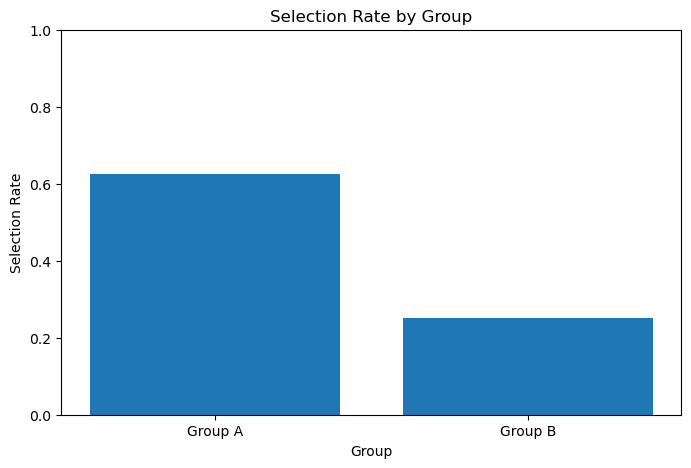

In [7]:
plt.figure(figsize=(8,5))
plt.bar(metrics_df["group"], metrics_df["selection_rate"])
plt.title("Selection Rate by Group")
plt.xlabel("Group")
plt.ylabel("Selection Rate")
plt.ylim(0, 1)
plt.show()

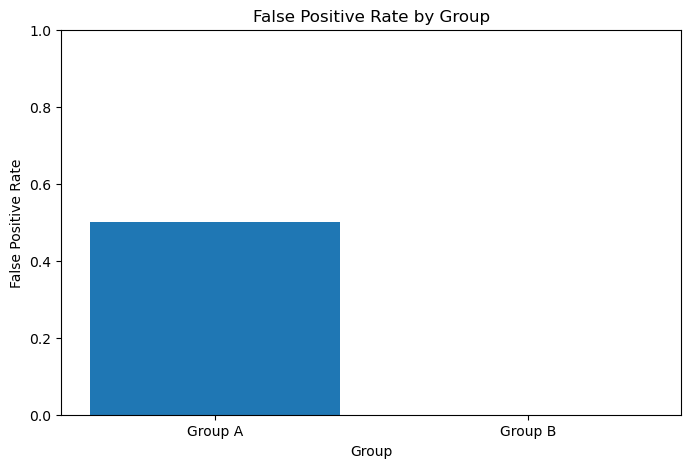

In [8]:
plt.figure(figsize=(8,5))
plt.bar(metrics_df["group"], metrics_df["false_positive_rate"])
plt.title("False Positive Rate by Group")
plt.xlabel("Group")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.show()

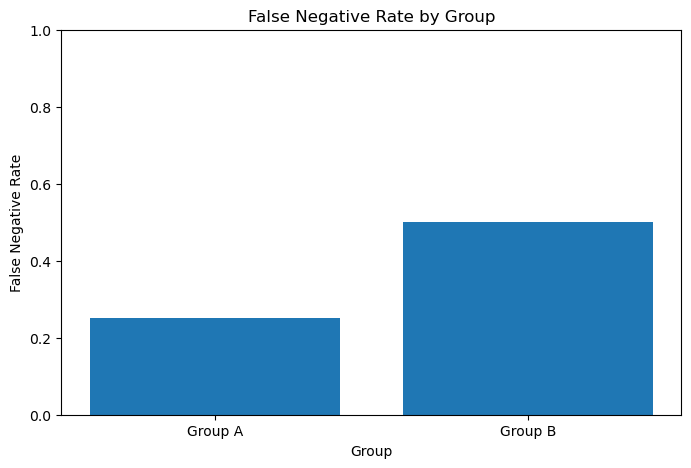

In [9]:
plt.figure(figsize=(8,5))
plt.bar(metrics_df["group"], metrics_df["false_negative_rate"])
plt.title("False Negative Rate by Group")
plt.xlabel("Group")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.show()

In [11]:
def disparity_check(metrics_df):
    if len(metrics_df) < 2:
        print("Need at least two groups to compare.")
        return

    for metric in ["selection_rate", "accuracy", "false_positive_rate", "false_negative_rate"]:
        gap = metrics_df[metric].max() - metrics_df[metric].min()
        print(f"{metric}: gap = {gap:.3f}")

disparity_check(metrics_df)

selection_rate: gap = 0.375
accuracy: gap = 0.125
false_positive_rate: gap = 0.500
false_negative_rate: gap = 0.250


## Interpretation of Results

The results indicate meaningful disparities between Group A and Group B.

Group A has a significantly higher selection rate (0.625) compared to Group B (0.250), meaning the model is much more likely to assign a positive prediction to Group A. Additionally, the false positive rate for Group A (0.50) is substantially higher than for Group B (0.00), indicating that Group A is more likely to be incorrectly given positive outcomes.

On the other hand, Group B has a higher false negative rate (0.50 vs. 0.25), meaning individuals in Group B are more likely to be incorrectly denied a positive outcome.

These disparities suggest that the model treats the two groups differently, which may lead to unfair outcomes depending on the real-world context. For example, in a loan approval setting, this could mean that one group is more likely to receive incorrect approvals while another is more likely to be unfairly denied.

This highlights the importance of auditing models for fairness before deployment.

## Ethical Framework: NIST AI Risk Management Framework

This project aligns with the NIST AI Risk Management Framework by supporting the identification and measurement of risks associated with biased AI systems.

- **Map**: The tool defines the context in which a model is used and identifies potential stakeholders affected by its predictions.
- **Measure**: It computes fairness metrics such as selection rate and error rates across groups to quantify disparities.
- **Manage**: By highlighting differences between groups, the tool helps users recognize potential harms and consider corrective actions.
- **Govern**: The project encourages responsible AI use by promoting transparency and awareness of model behavior.

By providing a simple way to audit model outputs, this tool contributes to more trustworthy and ethical AI deployment.

## Example Use Case

This tool can be applied in high-stakes decision-making contexts such as loan approvals, hiring systems, or college admissions.

In these settings, biased predictions can lead to unequal access to opportunities. For instance, a higher false negative rate for one group could result in qualified individuals being unfairly denied loans or jobs.

By identifying these disparities early, FairCheck helps organizations take steps to reduce harm and improve fairness before deploying models in real-world environments.

## Limitations

This tool provides a basic assessment of fairness but has several limitations:

- Fairness metrics can sometimes conflict, and no single metric fully captures fairness.
- The analysis depends on the availability and accuracy of group labels, which may not always be present or appropriate to use.
- Equal metrics across groups do not necessarily guarantee that a system is fair in a broader social or ethical sense.
- Context matters: the impact of errors (false positives vs. false negatives) can vary depending on the application.

Therefore, this tool should be used as an initial diagnostic rather than a complete solution to bias in AI systems.

In [12]:
def flag_bias(metrics_df, threshold=0.2):
    print("Bias Check:")

    for metric in ["selection_rate", "false_positive_rate", "false_negative_rate"]:
        gap = metrics_df[metric].max() - metrics_df[metric].min()
        
        if gap > threshold:
            print(f"⚠️ Potential bias detected in {metric} (gap = {gap:.3f})")
        else:
            print(f"✅ No major issue detected in {metric} (gap = {gap:.3f})")

flag_bias(metrics_df)

Bias Check:
⚠️ Potential bias detected in selection_rate (gap = 0.375)
⚠️ Potential bias detected in false_positive_rate (gap = 0.500)
⚠️ Potential bias detected in false_negative_rate (gap = 0.250)
